In [1]:
# Cell 1 - Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Cell 2 - Download Global Market Indices
indices = {
    'Nifty 50 (India)': '^NSEI',
    'S&P 500 (USA)': '^GSPC',
    'NASDAQ (USA)': '^IXIC',
    'FTSE 100 (UK)': '^FTSE',
    'DAX (Germany)': '^GDAXI',
    'Nikkei 225 (Japan)': '^N225',
    'Hang Seng (Hong Kong)': '^HSI',
    'Shanghai (China)': '000001.SS',
    'KOSPI (South Korea)': '^KS11'
}

# Download 1 year data for all indices
data = yf.download(list(indices.values()), period="1y", interval="1d")['Close']

print("Data downloaded successfully!")
print("Shape:", data.shape)

[*********************100%***********************]  9 of 9 completed

Data downloaded successfully!
Shape: (262, 9)


In [3]:
# Cell 3 - Calculate Annual and YTD Returns for All Indices
first_price = data.dropna().iloc[0]
last_price = data.dropna().iloc[-1]

# YTD - from Jan 1 2026
ytd_start = data[data.index >= '2026-01-01'].dropna().iloc[0]

annual_returns = ((last_price - first_price) / first_price * 100).round(2)
ytd_returns = ((last_price - ytd_start) / ytd_start * 100).round(2)

# Rename columns from ticker symbols to readable names
ticker_to_name = {v: k for k, v in indices.items()}
annual_returns.index = [ticker_to_name.get(t, t) for t in annual_returns.index]
ytd_returns.index = [ticker_to_name.get(t, t) for t in ytd_returns.index]

annual_returns = annual_returns.sort_values(ascending=False)
ytd_returns = ytd_returns.sort_values(ascending=False)

print("=== Annual Returns (May 2025 - May 2026) ===")
print(annual_returns)
print("\n=== YTD Returns (Jan 2026 - May 2026) ===")
print(ytd_returns)

=== Annual Returns (May 2025 - May 2026) ===
KOSPI (South Korea)      174.57
Nikkei 225 (Japan)        60.34
NASDAQ (USA)              39.20
S&P 500 (USA)             27.18
Shanghai (China)          22.87
FTSE 100 (UK)             18.73
Hang Seng (Hong Kong)      7.65
DAX (Germany)              2.55
Nifty 50 (India)          -4.65
dtype: float64

=== YTD Returns (Jan 2026 - May 2026) ===
KOSPI (South Korea)      61.73
Nikkei 225 (Japan)       15.38
NASDAQ (USA)             12.29
S&P 500 (USA)             7.69
FTSE 100 (UK)             4.28
Shanghai (China)          3.45
DAX (Germany)            -0.53
Hang Seng (Hong Kong)    -2.64
Nifty 50 (India)         -9.87
dtype: float64


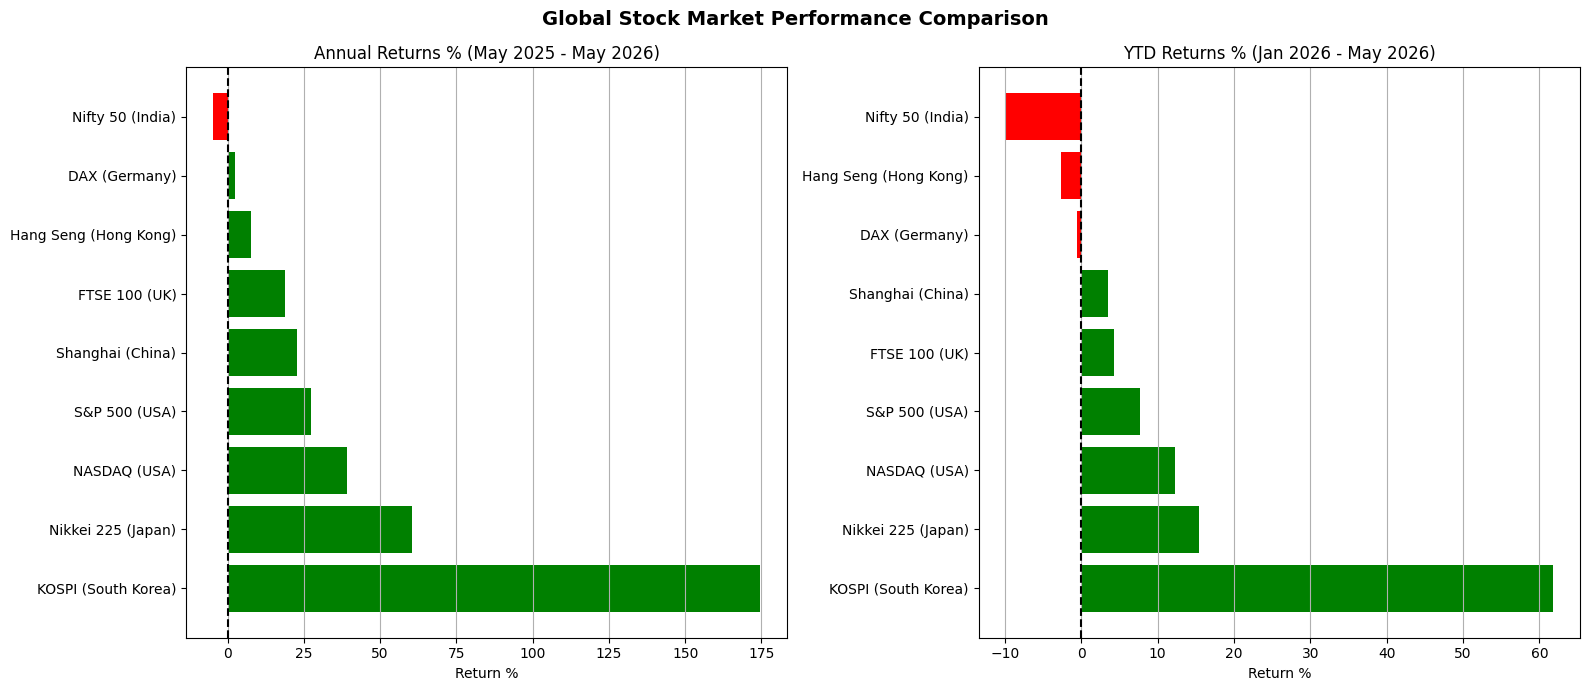

In [4]:
# Cell 4 - Plot Annual vs YTD Returns Comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Annual Returns
colors1 = ['green' if x > 0 else 'red' for x in annual_returns.values]
ax1.barh(annual_returns.index, annual_returns.values, color=colors1)
ax1.axvline(x=0, color='black', linestyle='--')
ax1.set_title('Annual Returns % (May 2025 - May 2026)')
ax1.set_xlabel('Return %')
ax1.grid(True, axis='x')

# YTD Returns
colors2 = ['green' if x > 0 else 'red' for x in ytd_returns.values]
ax2.barh(ytd_returns.index, ytd_returns.values, color=colors2)
ax2.axvline(x=0, color='black', linestyle='--')
ax2.set_title('YTD Returns % (Jan 2026 - May 2026)')
ax2.set_xlabel('Return %')
ax2.grid(True, axis='x')

plt.suptitle('Global Stock Market Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

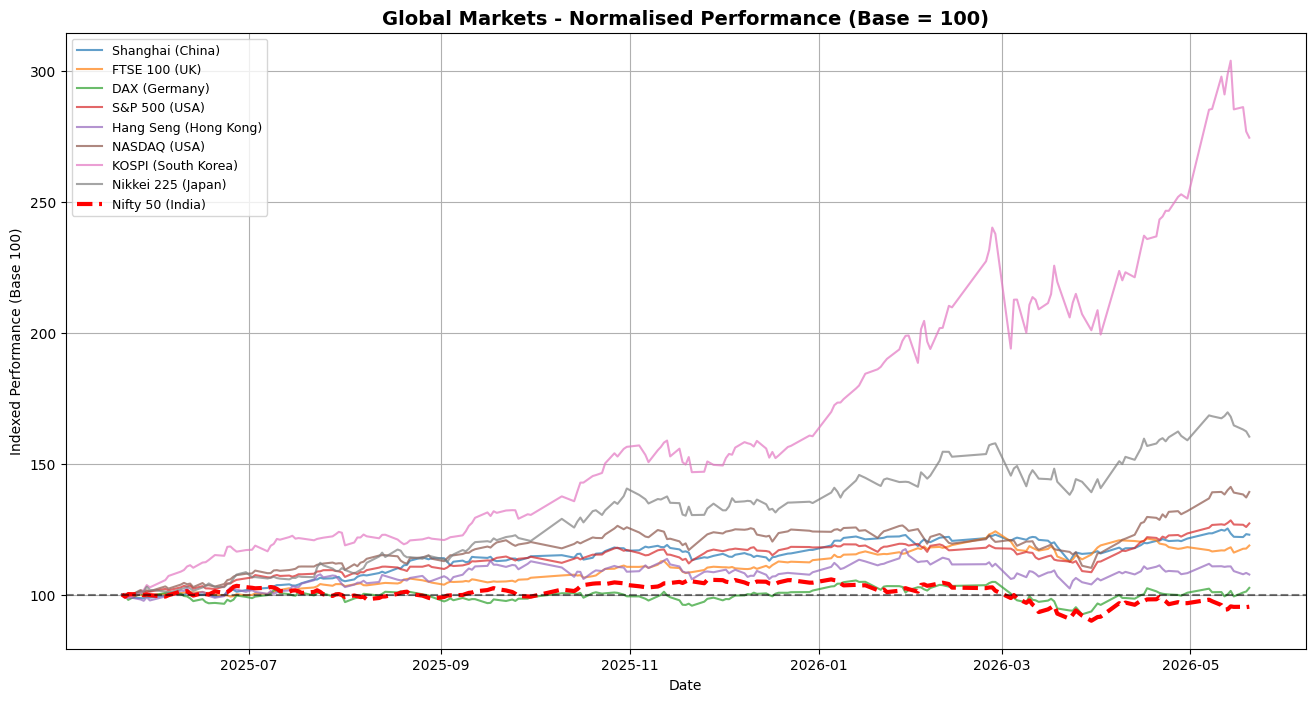

In [5]:
# Cell 5 - Normalised Price Chart (All indices starting from 100)
normalized = data.dropna() / data.dropna().iloc[0] * 100

# Rename columns
normalized.columns = [ticker_to_name.get(t, t) for t in normalized.columns]

plt.figure(figsize=(16, 8))
for column in normalized.columns:
    if column == 'Nifty 50 (India)':
        plt.plot(normalized[column], linewidth=3, linestyle='--', label=column, color='red')
    else:
        plt.plot(normalized[column], linewidth=1.5, alpha=0.7, label=column)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.5)
plt.title('Global Markets - Normalised Performance (Base = 100)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Indexed Performance (Base 100)')
plt.legend(loc='upper left', fontsize=9)
plt.grid(True)
plt.show()

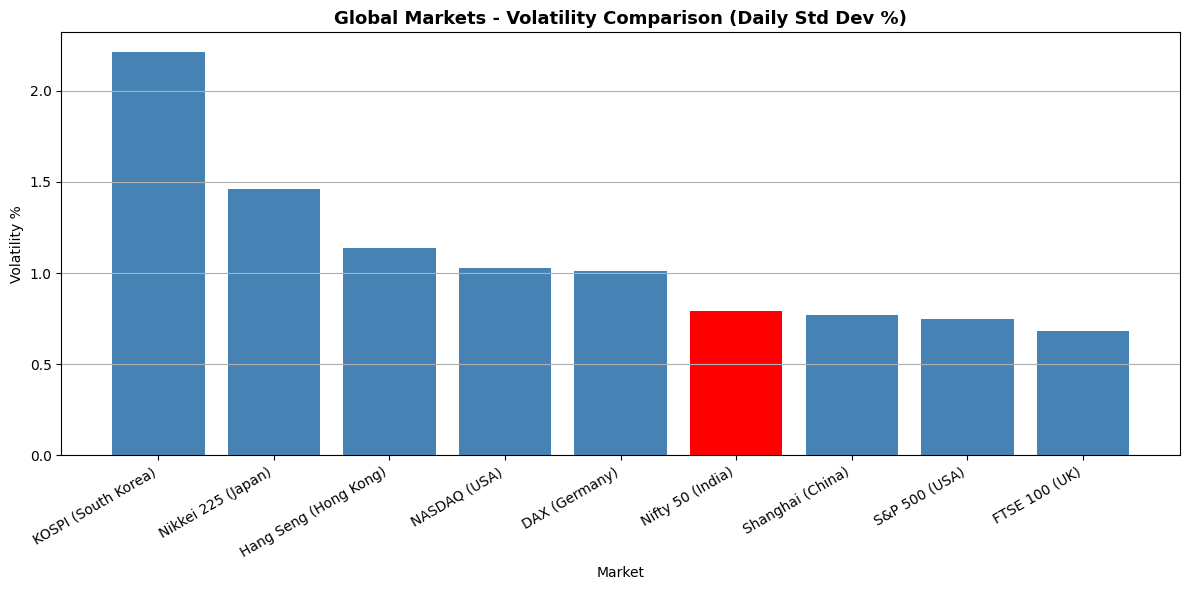

In [6]:
# Cell 6 - Volatility Comparison Across Markets
volatility = {}
for col in data.columns:
    returns = data[col].pct_change() * 100
    volatility[ticker_to_name[col]] = returns.std().round(2)

vol_series = pd.Series(volatility).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['red' if 'India' in x else 'steelblue' for x in vol_series.index]
plt.bar(vol_series.index, vol_series.values, color=colors)
plt.title('Global Markets - Volatility Comparison (Daily Std Dev %)', fontsize=13, fontweight='bold')
plt.xlabel('Market')
plt.ylabel('Volatility %')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

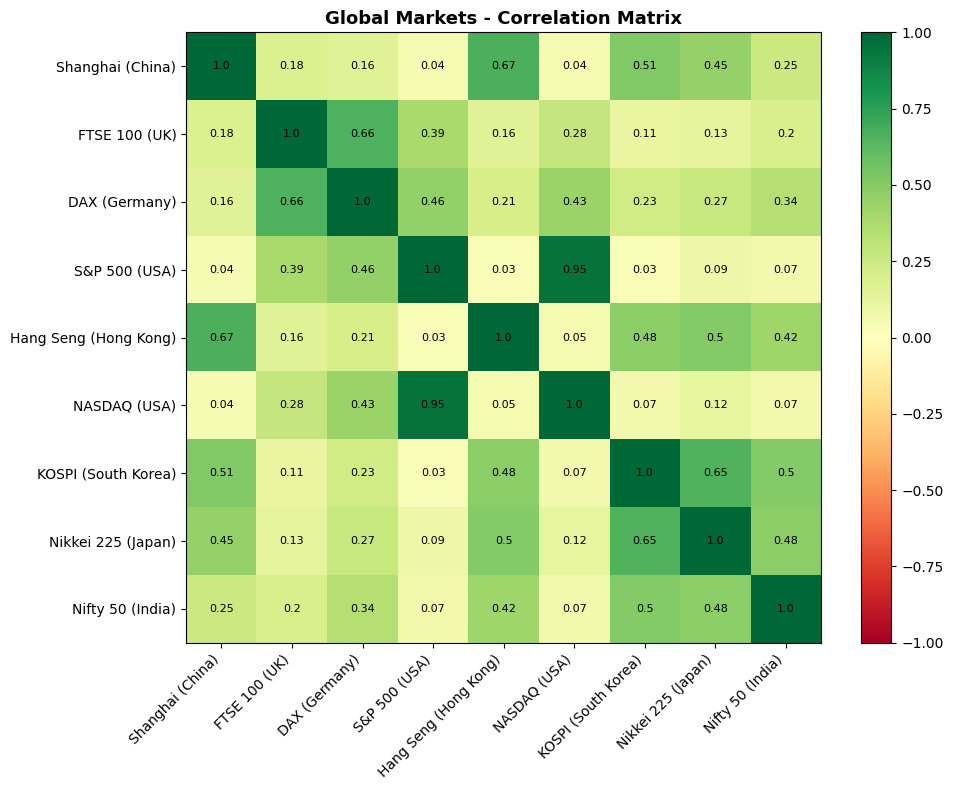

In [7]:
# Cell 7 - Correlation Matrix
daily_returns = data.pct_change().dropna()
daily_returns.columns = [ticker_to_name.get(t, t) for t in daily_returns.columns]

correlation = daily_returns.corr().round(2)

plt.figure(figsize=(10, 8))
im = plt.imshow(correlation, cmap='RdYlGn', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45, ha='right')
plt.yticks(range(len(correlation.columns)), correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, str(correlation.iloc[i, j]), ha='center', va='center', fontsize=8)

plt.title('Global Markets - Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


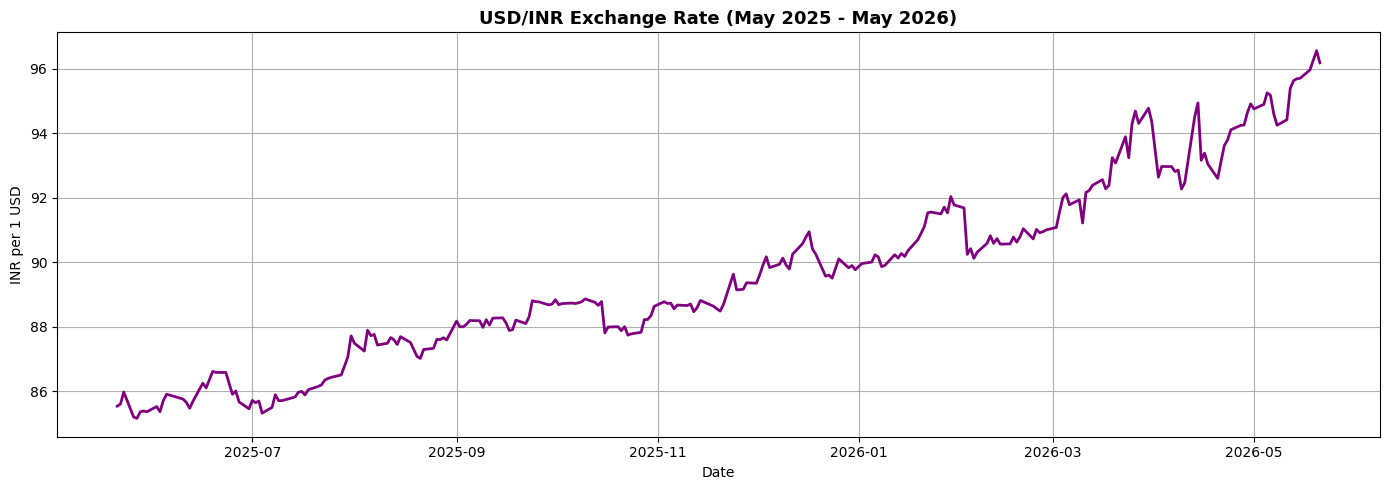

Rupee depreciation over 1 year: 12.46%


In [8]:
# Cell 8 - USD/INR Exchange Rate Analysis
usdinr = yf.download('INR=X', period='1y', interval='1d')['Close']

plt.figure(figsize=(14, 5))
plt.plot(usdinr, color='purple', linewidth=2)
plt.title('USD/INR Exchange Rate (May 2025 - May 2026)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('INR per 1 USD')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate rupee depreciation
first_rate = usdinr.dropna().iloc[0].squeeze()
last_rate = usdinr.dropna().iloc[-1].squeeze()
depreciation = ((last_rate - first_rate) / first_rate * 100).round(2)
print(f"Rupee depreciation over 1 year: {depreciation}%")

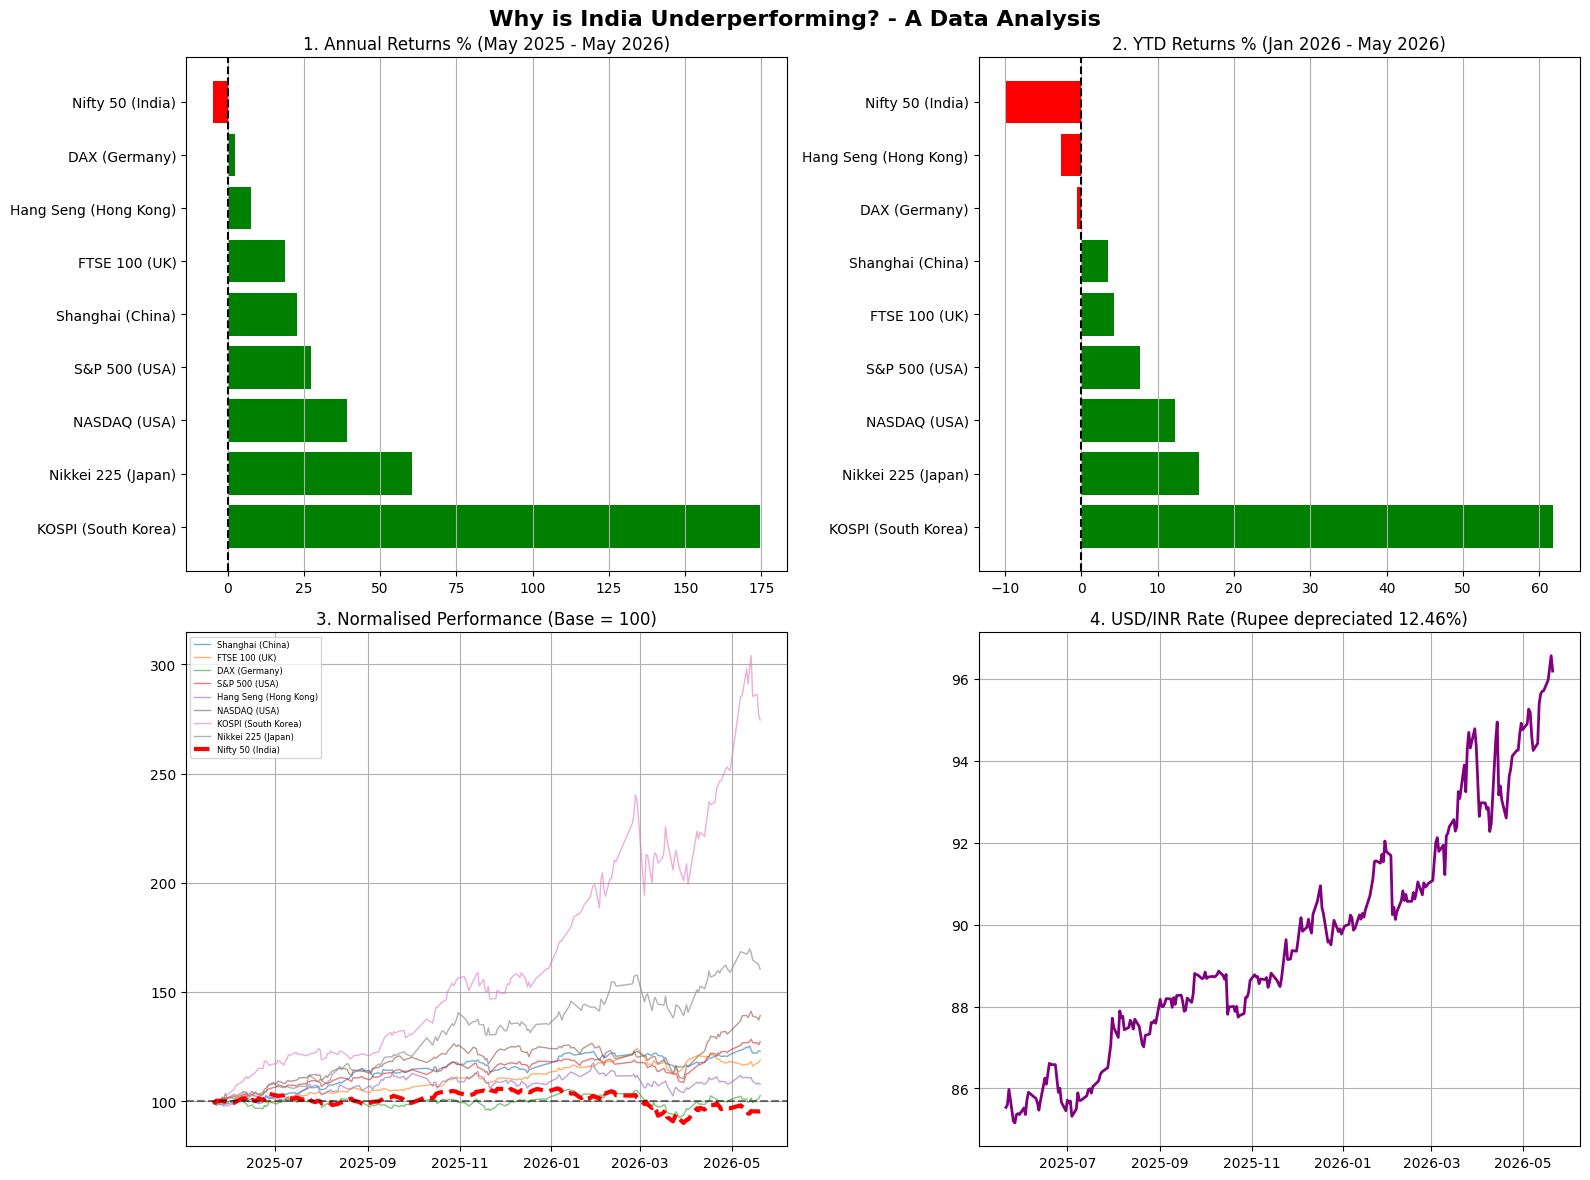

In [9]:
# Cell 9 - Final Summary - India vs World Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Why is India Underperforming? - A Data Analysis', 
             fontsize=16, fontweight='bold')

# Chart 1 - Annual Returns
ax1 = axes[0, 0]
colors1 = ['red' if x < 0 else 'green' for x in annual_returns.values]
ax1.barh(annual_returns.index, annual_returns.values, color=colors1)
ax1.axvline(x=0, color='black', linestyle='--')
ax1.set_title('1. Annual Returns % (May 2025 - May 2026)')
ax1.grid(True, axis='x')

# Chart 2 - YTD Returns
ax2 = axes[0, 1]
colors2 = ['red' if x < 0 else 'green' for x in ytd_returns.values]
ax2.barh(ytd_returns.index, ytd_returns.values, color=colors2)
ax2.axvline(x=0, color='black', linestyle='--')
ax2.set_title('2. YTD Returns % (Jan 2026 - May 2026)')
ax2.grid(True, axis='x')

# Chart 3 - Normalised Performance
ax3 = axes[1, 0]
for col in normalized.columns:
    if col == 'Nifty 50 (India)':
        ax3.plot(normalized[col], linewidth=3, linestyle='--', label=col, color='red')
    else:
        ax3.plot(normalized[col], linewidth=1, alpha=0.6, label=col)
ax3.axhline(y=100, color='black', linestyle='--', alpha=0.5)
ax3.set_title('3. Normalised Performance (Base = 100)')
ax3.legend(fontsize=6)
ax3.grid(True)

# Chart 4 - USD/INR
ax4 = axes[1, 1]
ax4.plot(usdinr, color='purple', linewidth=2)
ax4.set_title(f'4. USD/INR Rate (Rupee depreciated {depreciation}%)')
ax4.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Cell 10 - Key Findings Summary
print("""
╔══════════════════════════════════════════════════════════════╗
║     WHY IS INDIA UNDERPERFORMING? - KEY FINDINGS             ║
╠══════════════════════════════════════════════════════════════╣
║ 1. RETURNS: Nifty -4.65% annually, -9.87% YTD               ║
║    → Only market with negative annual returns                ║
║                                                              ║
║ 2. CURRENCY: Rupee depreciated 12.46% vs USD                 ║
║    → Foreign investors lost ~17% in dollar terms            ║
║                                                              ║
║ 3. DECOUPLING: India-NASDAQ correlation only 0.07            ║
║    → India did not participate in global rally               ║
║                                                              ║
║ 4. VOLATILITY: India moderate at 0.8%                        ║
║    → Slow steady decline, not a panic crash                  ║
║                                                              ║
║ 5. SECTOR: IT (-14%) and Banking (-22%) dragging India       ║
║    → Two biggest Nifty sectors both underperforming          ║
║                                                              ║
║ CONCLUSION: India's underperformance is structural —         ║
║ driven by rupee weakness, FII outflows, IT sector            ║
║ slowdown and premium valuations vs global peers              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║     WHY IS INDIA UNDERPERFORMING? - KEY FINDINGS             ║
╠══════════════════════════════════════════════════════════════╣
║ 1. RETURNS: Nifty -4.65% annually, -9.87% YTD               ║
║    → Only market with negative annual returns                ║
║                                                              ║
║ 2. CURRENCY: Rupee depreciated 12.46% vs USD                 ║
║    → Foreign investors lost ~17% in dollar terms            ║
║                                                              ║
║ 3. DECOUPLING: India-NASDAQ correlation only 0.07            ║
║    → India did not participate in global rally               ║
║                                                              ║
║ 4. VOLATILITY: India moderate at 0.8%                        ║
║    → Slow steady decline, not a panic crash                  ║
║                                                              ║
║ 5. SECTOR: IT (-14%) and